# 02 - Modelado Predictivo y Evaluación

Este notebook corrige el leakage metodológico: cada fold de validación ajusta winsorización, ingeniería, selección, `SMOTENC` y escalado únicamente con el sub-train del fold. El test se usa una sola vez al final para estimar generalización.

In [1]:
from pathlib import Path
import json
import pickle
import sys
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy import stats
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import optuna
from xgboost import XGBClassifier

ROOT = Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from app.f1_pipeline import (
    DEFAULT_SELECTED_FEATURES,
    FeatureEngineer,
    LeakageColumnDropper,
    ColumnSelector,
    Winsorizer,
    smotenc_feature_indices,
)

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
RANDOM_STATE = 42
OUTPUT_DIR = ROOT / 'output'
MODELS_DIR = ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid')

/home/creep/.local/share/uv/python/cpython-3.11-linux-x86_64-gnu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_original = pd.read_csv(OUTPUT_DIR / 'train_original.csv')
test_original = pd.read_csv(OUTPUT_DIR / 'test_unbalanced_raw.csv')

X_train = train_original.drop(columns=['finished'])
y_train = train_original['finished']
X_test = test_original.drop(columns=['finished'])
y_test = test_original['finished']

print(f'Train original para CV: {X_train.shape}; clases {y_train.value_counts().sort_index().to_dict()}')
print(f'Test reservado: {X_test.shape}; clases {y_test.value_counts().sort_index().to_dict()}')

Train original para CV: (16643, 28); clases {0: 12437, 1: 4206}
Test reservado: (7134, 28); clases {0: 5331, 1: 1803}


In [3]:
selected_features = DEFAULT_SELECTED_FEATURES
cat_indices = smotenc_feature_indices(selected_features)

def build_pipeline(model):
    return ImbPipeline([
        ('drop_leakage', LeakageColumnDropper()),
        ('feature_engineering', FeatureEngineer()),
        ('winsorizer', Winsorizer()),
        ('selector', ColumnSelector(selected_features)),
        ('sampler', SMOTENC(categorical_features=cat_indices, random_state=RANDOM_STATE, k_neighbors=5)),
        ('scaler', StandardScaler()),
        ('model', model),
    ])

base_models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight=None, random_state=RANDOM_STATE),
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=11),
    'NaiveBayes': GaussianNB(),
    'RandomForest': RandomForestClassifier(n_estimators=160, max_depth=10, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=120, learning_rate=0.06, max_depth=3, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=140, max_depth=3, learning_rate=0.06, subsample=0.9, colsample_bytree=0.9, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=2),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

In [4]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_metrics = {
    'Accuracy': accuracy_score(y_test, baseline_pred),
    'Precision': precision_score(y_test, baseline_pred, zero_division=0),
    'Recall': recall_score(y_test, baseline_pred, zero_division=0),
    'F1': f1_score(y_test, baseline_pred, zero_division=0),
}
display(pd.Series(baseline_metrics, name='baseline_mayoritaria').to_frame().round(4))

,baseline_mayoritaria
Accuracy,0.7473
Precision,0.0000
Recall,0.0000
F1,0.0000


In [5]:
cv_rows = []
fold_rows = []
fitted_models = {}
test_rows = []

for name, estimator in base_models.items():
    pipe = build_pipeline(estimator)
    print(f'Validando {name}...', end=' ')
    start = time.time()
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)
    elapsed = time.time() - start

    for fold, f1 in enumerate(scores['test_f1'], start=1):
        fold_rows.append({'Modelo': name, 'fold': fold, 'F1': f1})

    row = {'Modelo': name, 'Tiempo_s': elapsed}
    for metric in scoring:
        row[f'CV_{metric}_mean'] = scores[f'test_{metric}'].mean()
        row[f'CV_{metric}_std'] = scores[f'test_{metric}'].std()
    row['Train_F1_mean'] = scores['train_f1'].mean()
    row['Gap_Train_CV_F1'] = row['Train_F1_mean'] - row['CV_f1_mean']
    cv_rows.append(row)

    fitted = clone(pipe).fit(X_train, y_train)
    fitted_models[name] = fitted
    pred = fitted.predict(X_test)
    prob = fitted.predict_proba(X_test)[:, 1]
    test_rows.append({
        'Modelo': name,
        'Test_Accuracy': accuracy_score(y_test, pred),
        'Test_Precision': precision_score(y_test, pred, zero_division=0),
        'Test_Recall': recall_score(y_test, pred, zero_division=0),
        'Test_F1': f1_score(y_test, pred, zero_division=0),
        'Test_ROC_AUC': roc_auc_score(y_test, prob),
    })
    print(f"CV F1={row['CV_f1_mean']:.4f}; Test F1={test_rows[-1]['Test_F1']:.4f}; {elapsed:.1f}s")

cv_df = pd.DataFrame(cv_rows).sort_values('CV_f1_mean', ascending=False)
fold_df = pd.DataFrame(fold_rows)
test_df = pd.DataFrame(test_rows).sort_values('Test_F1', ascending=False)

cv_df.to_csv(OUTPUT_DIR / 'comparativa_modelos_cv.csv', index=False)
test_df.to_csv(OUTPUT_DIR / 'comparativa_modelos_test_informativo.csv', index=False)
fold_df.to_csv(OUTPUT_DIR / 'f1_folds_modelos.csv', index=False)

display(cv_df.round(4))
display(test_df.round(4))

Validando LogisticRegression... 

CV F1=0.6404; Test F1=0.6349; 1.6s
Validando SVM... 

CV F1=0.6389; Test F1=0.6300; 36.2s
Validando KNN... 

CV F1=0.6201; Test F1=0.6213; 3.4s
Validando NaiveBayes... 

CV F1=0.6286; Test F1=0.6281; 0.9s
Validando RandomForest... 

CV F1=0.6516; Test F1=0.6385; 2.1s
Validando GradientBoosting... 

CV F1=0.6454; Test F1=0.6334; 6.3s
Validando XGBoost... 

CV F1=0.6443; Test F1=0.6321; 1.3s


,Modelo,Tiempo_s,CV_accuracy_mean,CV_accuracy_std,CV_precision_mean,CV_precision_std,CV_recall_mean,CV_recall_std,CV_f1_mean,CV_f1_std,CV_roc_auc_mean,CV_roc_auc_std,Train_F1_mean,Gap_Train_CV_F1
4,RandomForest,2.1368,0.8016,0.0061,0.5859,0.0106,0.7340,0.0097,0.6516,0.0086,0.8656,0.0068,0.7178,0.0662
5,GradientBoosting,6.2530,0.8080,0.0069,0.6053,0.0137,0.6914,0.0098,0.6454,0.0102,0.8665,0.0062,0.6561,0.0107
6,XGBoost,1.2705,0.8068,0.0056,0.6026,0.0116,0.6923,0.0123,0.6443,0.0082,0.8681,0.0058,0.6567,0.0124
0,LogisticRegression,1.5880,0.7845,0.0085,0.5540,0.0127,0.7589,0.0137,0.6404,0.0116,0.8539,0.0072,0.6421,0.0017
1,SVM,36.1964,0.7809,0.0083,0.5476,0.0121,0.7668,0.0138,0.6389,0.0112,0.8427,0.0081,0.6720,0.0332
3,NaiveBayes,0.8575,0.7940,0.0044,0.5775,0.0079,0.6897,0.0084,0.6286,0.0066,0.8438,0.0060,0.6292,0.0006
2,KNN,3.4008,0.7722,0.0060,0.5360,0.0089,0.7359,0.0147,0.6201,0.0078,0.8383,0.0059,0.6845,0.0644


,Modelo,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
4,RandomForest,0.7910,0.5672,0.7304,0.6385,0.8603
0,LogisticRegression,0.7785,0.5442,0.7621,0.6349,0.8488
5,GradientBoosting,0.7993,0.5882,0.6861,0.6334,0.8611
6,XGBoost,0.7989,0.5877,0.6839,0.6321,0.8620
1,SVM,0.7738,0.5369,0.7621,0.6300,0.8373
3,NaiveBayes,0.7928,0.5749,0.6922,0.6281,0.8428
2,KNN,0.7707,0.5332,0.7443,0.6213,0.8378


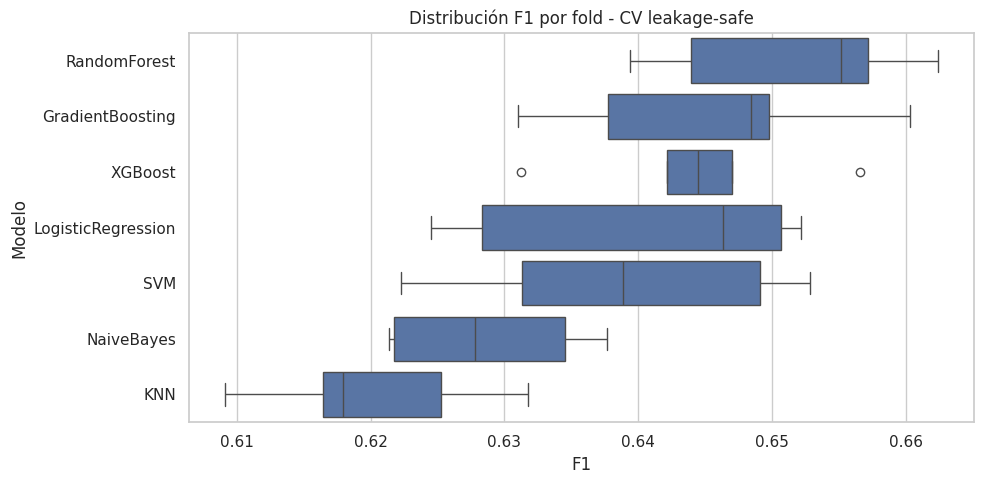

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=fold_df, x='F1', y='Modelo', order=cv_df['Modelo'], ax=ax)
ax.set_title('Distribución F1 por fold - CV leakage-safe')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cv_f1_boxplot.png', dpi=140, bbox_inches='tight')
plt.show()

## ANOVA y Tukey para selección de los 3 mejores

In [7]:
groups = [group['F1'].values for _, group in fold_df.groupby('Modelo')]
anova_stat, anova_p = stats.f_oneway(*groups)
print(f'ANOVA F={anova_stat:.4f}, p-value={anova_p:.6f}')

tukey = pairwise_tukeyhsd(endog=fold_df['F1'], groups=fold_df['Modelo'], alpha=0.05)
print(tukey)

top3_names = cv_df.head(3)['Modelo'].tolist()
print('Top 3 seleccionados por F1 medio de CV:', top3_names)

with open(OUTPUT_DIR / 'anova_tukey.txt', 'w', encoding='utf-8') as f:
    f.write(f'ANOVA F={anova_stat:.6f}, p-value={anova_p:.8f}\n\n')
    f.write(str(tukey))
    f.write(f'\n\nTop 3 por CV F1: {top3_names}\n')

ANOVA F=5.3052, p-value=0.000922


            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2       meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------
  GradientBoosting                KNN  -0.0253 0.0102 -0.0462 -0.0044   True
  GradientBoosting LogisticRegression   -0.005 0.9865  -0.026  0.0159  False
  GradientBoosting         NaiveBayes  -0.0168 0.1803 -0.0377  0.0041  False
  GradientBoosting       RandomForest   0.0062 0.9636 -0.0148  0.0271  False
  GradientBoosting                SVM  -0.0066 0.9506 -0.0275  0.0143  False
  GradientBoosting            XGBoost  -0.0012    1.0 -0.0221  0.0198  False
               KNN LogisticRegression   0.0203 0.0622 -0.0006  0.0412  False
               KNN         NaiveBayes   0.0085 0.8512 -0.0124  0.0294  False
               KNN       RandomForest   0.0315 0.0009  0.0106  0.0524   True
               KNN                SVM   0.0187 0.1017 -0.0022  0.0396  False

## Hiperparametrización de los 3 mejores

Se aplican dos estrategias a cada modelo seleccionado: `GridSearchCV` y optimización bayesiana con Optuna. La selección final se hace con F1 de CV interno ajustado por sobreajuste; el test sigue reservado para la evaluación final.

Regla de control: el modelo desplegable debe cumplir `abs(F1_train - F1_test) <= 0.05`. Para empujar esa condición sin contaminar el test, se penalizan candidatos cuya brecha `F1_train_CV - F1_validacion_CV` supere 5 puntos porcentuales durante la optimización interna.

In [8]:
MAX_F1_GAP = 0.05
GAP_PENALTY_WEIGHT = 2.0

def adjusted_cv_score(cv_f1, train_f1):
    gap = max(0.0, train_f1 - cv_f1)
    penalty = max(0.0, gap - MAX_F1_GAP) * GAP_PENALTY_WEIGHT
    return cv_f1 - penalty

param_grids = {
    'LogisticRegression': {
        'model__C': [0.05, 0.1, 0.3, 1.0],
        'model__penalty': ['l2'],
        'model__solver': ['lbfgs'],
    },
    'SVM': {
        'model__C': [0.5, 1.0, 2.0],
        'model__gamma': ['scale', 0.01],
        'model__kernel': ['rbf'],
    },
    'KNN': {
        'model__n_neighbors': [7, 11, 17],
        'model__weights': ['uniform', 'distance'],
    },
    'NaiveBayes': {'model__var_smoothing': [1e-9, 1e-8, 1e-7]},
    'RandomForest': {
        'model__n_estimators': [160, 220],
        'model__max_depth': [4, 6, 8],
        'model__min_samples_leaf': [20, 50, 80],
        'model__min_samples_split': [40, 100],
    },
    'GradientBoosting': {
        'model__n_estimators': [80, 120, 140],
        'model__learning_rate': [0.04, 0.06],
        'model__max_depth': [1, 2],
        'model__min_samples_leaf': [20],
    },
    'XGBoost': {
        'model__n_estimators': [100, 140],
        'model__max_depth': [1, 2],
        'model__learning_rate': [0.04, 0.06],
        'model__min_child_weight': [10],
        'model__reg_lambda': [8],
        'model__reg_alpha': [0.5],
    },
}

def suggest_estimator(name, trial):
    if name == 'LogisticRegression':
        return LogisticRegression(C=trial.suggest_float('C', 0.05, 5.0, log=True), max_iter=1000, random_state=RANDOM_STATE)
    if name == 'SVM':
        return SVC(C=trial.suggest_float('C', 0.3, 4.0, log=True), gamma=trial.suggest_categorical('gamma', ['scale', 0.005, 0.02]), kernel='rbf', probability=True, random_state=RANDOM_STATE)
    if name == 'KNN':
        return KNeighborsClassifier(n_neighbors=trial.suggest_int('n_neighbors', 5, 21, step=2), weights=trial.suggest_categorical('weights', ['uniform', 'distance']))
    if name == 'NaiveBayes':
        return GaussianNB(var_smoothing=trial.suggest_float('var_smoothing', 1e-10, 1e-6, log=True))
    if name == 'RandomForest':
        leaf = trial.suggest_int('min_samples_leaf', 20, 90, step=10)
        return RandomForestClassifier(n_estimators=trial.suggest_int('n_estimators', 120, 240, step=40), max_depth=trial.suggest_int('max_depth', 3, 8), min_samples_leaf=leaf, min_samples_split=max(40, leaf * 2), random_state=RANDOM_STATE, n_jobs=-1)
    if name == 'GradientBoosting':
        return GradientBoostingClassifier(n_estimators=trial.suggest_int('n_estimators', 70, 150, step=20), learning_rate=trial.suggest_float('learning_rate', 0.03, 0.08), max_depth=trial.suggest_int('max_depth', 1, 2), min_samples_leaf=20, random_state=RANDOM_STATE)
    if name == 'XGBoost':
        return XGBClassifier(n_estimators=trial.suggest_int('n_estimators', 80, 160, step=40), max_depth=trial.suggest_int('max_depth', 1, 2), learning_rate=trial.suggest_float('learning_rate', 0.03, 0.08), min_child_weight=10, subsample=trial.suggest_float('subsample', 0.8, 1.0), colsample_bytree=trial.suggest_float('colsample_bytree', 0.8, 1.0), reg_lambda=8, reg_alpha=0.5, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=2)
    raise ValueError(name)

In [9]:
tuning_rows = []
best_candidates = []
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

for name in top3_names:
    print(f'Optimizando {name} con GridSearchCV...')
    grid = GridSearchCV(
        estimator=build_pipeline(base_models[name]),
        param_grid=param_grids[name],
        scoring='f1',
        cv=inner_cv,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_train, y_train)
    grid_check = cross_validate(grid.best_estimator_, X_train, y_train, cv=inner_cv, scoring={'f1': 'f1'}, n_jobs=-1, return_train_score=True)
    grid_cv_f1 = grid_check['test_f1'].mean()
    grid_train_f1 = grid_check['train_f1'].mean()
    grid_gap = grid_train_f1 - grid_cv_f1
    grid_adjusted = adjusted_cv_score(grid_cv_f1, grid_train_f1)
    tuning_rows.append({'Modelo': name, 'Metodo': 'GridSearchCV', 'CV_F1': grid_cv_f1, 'Train_CV_F1': grid_train_f1, 'Gap_Train_CV_F1': grid_gap, 'CV_F1_Ajustado': grid_adjusted, 'Params': grid.best_params_})
    best_candidates.append((f'{name}_GridSearchCV', grid_adjusted, grid_cv_f1, grid_train_f1, grid.best_estimator_))

    print(f'Optimizando {name} con Optuna...')
    def objective(trial):
        estimator = suggest_estimator(name, trial)
        pipe = build_pipeline(estimator)
        scores = cross_validate(pipe, X_train, y_train, cv=inner_cv, scoring={'f1': 'f1'}, n_jobs=-1, return_train_score=True)
        return adjusted_cv_score(scores['test_f1'].mean(), scores['train_f1'].mean())

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=8, show_progress_bar=False)
    optuna_unfit = build_pipeline(suggest_estimator(name, study.best_trial))
    optuna_check = cross_validate(optuna_unfit, X_train, y_train, cv=inner_cv, scoring={'f1': 'f1'}, n_jobs=-1, return_train_score=True)
    optuna_cv_f1 = optuna_check['test_f1'].mean()
    optuna_train_f1 = optuna_check['train_f1'].mean()
    optuna_gap = optuna_train_f1 - optuna_cv_f1
    optuna_adjusted = adjusted_cv_score(optuna_cv_f1, optuna_train_f1)
    optuna_pipe = clone(optuna_unfit).fit(X_train, y_train)
    tuning_rows.append({'Modelo': name, 'Metodo': 'Optuna', 'CV_F1': optuna_cv_f1, 'Train_CV_F1': optuna_train_f1, 'Gap_Train_CV_F1': optuna_gap, 'CV_F1_Ajustado': optuna_adjusted, 'Params': study.best_params})
    best_candidates.append((f'{name}_Optuna', optuna_adjusted, optuna_cv_f1, optuna_train_f1, optuna_pipe))

tuning_df = pd.DataFrame(tuning_rows).sort_values('CV_F1_Ajustado', ascending=False)
tuning_df.to_csv(OUTPUT_DIR / 'optimizacion_top3.csv', index=False)
display(tuning_df)

Optimizando RandomForest con GridSearchCV...


Optimizando RandomForest con Optuna...


Optimizando GradientBoosting con GridSearchCV...


Optimizando GradientBoosting con Optuna...


Optimizando XGBoost con GridSearchCV...


Optimizando XGBoost con Optuna...


,Modelo,Metodo,CV_F1,Train_CV_F1,Gap_Train_CV_F1,CV_F1_Ajustado,Params
0,RandomForest,GridSearchCV,0.646993,0.671781,0.024788,0.646993,"{'model__max_depth': 8, 'model__min_samples_le..."
5,XGBoost,Optuna,0.646187,0.650182,0.003995,0.646187,"{'n_estimators': 120, 'max_depth': 2, 'learnin..."
2,GradientBoosting,GridSearchCV,0.646170,0.649799,0.003629,0.646170,"{'model__learning_rate': 0.06, 'model__max_dep..."
3,GradientBoosting,Optuna,0.646016,0.649594,0.003578,0.646016,"{'n_estimators': 90, 'learning_rate': 0.077535..."
4,XGBoost,GridSearchCV,0.645425,0.648359,0.002934,0.645425,"{'model__learning_rate': 0.06, 'model__max_dep..."
1,RandomForest,Optuna,0.644061,0.654817,0.010756,0.644061,"{'min_samples_leaf': 30, 'n_estimators': 160, ..."


## Evaluación final en test reservado

In [10]:
best_name, best_adjusted_cv_f1, best_cv_f1, best_cv_train_f1, best_pipe = sorted(best_candidates, key=lambda item: item[1], reverse=True)[0]
final_train_pred = best_pipe.predict(X_train)
final_pred = best_pipe.predict(X_test)
final_prob = best_pipe.predict_proba(X_test)[:, 1]
final_train_f1 = f1_score(y_train, final_train_pred, zero_division=0)
final_test_f1 = f1_score(y_test, final_pred, zero_division=0)
final_train_test_gap = abs(final_train_f1 - final_test_f1)
gap_status = 'APROBADO' if final_train_test_gap <= MAX_F1_GAP else 'RECHAZADO'

final_metrics = {
    'Modelo': best_name,
    'CV_F1_Ajustado': best_adjusted_cv_f1,
    'CV_F1_seleccion': best_cv_f1,
    'CV_Train_F1_seleccion': best_cv_train_f1,
    'Train_F1_final': final_train_f1,
    'Accuracy': accuracy_score(y_test, final_pred),
    'Precision': precision_score(y_test, final_pred, zero_division=0),
    'Recall': recall_score(y_test, final_pred, zero_division=0),
    'F1': final_test_f1,
    'ROC_AUC': roc_auc_score(y_test, final_prob),
    'Gap_CV_Test_F1': best_cv_f1 - final_test_f1,
    'Gap_Train_Test_F1': final_train_test_gap,
    'Criterio_Gap_Train_Test_Max': MAX_F1_GAP,
    'Estado_Gap_Train_Test': gap_status,
}

metricas_finales = pd.DataFrame([final_metrics])
metricas_finales.to_csv(OUTPUT_DIR / 'metricas_finales.csv', index=False)
joblib.dump(best_pipe, MODELS_DIR / 'best_model_pipe.pkl')

cm = confusion_matrix(y_test, final_pred)
pd.DataFrame(cm, index=['real_0', 'real_1'], columns=['pred_0', 'pred_1']).to_csv(OUTPUT_DIR / 'confusion_matrix_final.csv')

display(metricas_finales.round(4))
display(pd.DataFrame(cm, index=['real_0', 'real_1'], columns=['pred_0', 'pred_1']))
if gap_status != 'APROBADO':
    raise RuntimeError(f'El modelo final no cumple la brecha máxima de F1 train-test: {final_train_test_gap:.4f} > {MAX_F1_GAP:.4f}')
print(f'Pipeline final guardado en {MODELS_DIR / "best_model_pipe.pkl"}')
print('Pasos del pipeline:', list(best_pipe.named_steps.keys()))
print(f'Criterio de brecha F1 train-test: {gap_status} ({final_train_test_gap:.4f} <= {MAX_F1_GAP:.4f})')

,Modelo,CV_F1_Ajustado,CV_F1_seleccion,CV_Train_F1_seleccion,Train_F1_final,Accuracy,Precision,Recall,F1,ROC_AUC,Gap_CV_Test_F1,Gap_Train_Test_F1,Criterio_Gap_Train_Test_Max,Estado_Gap_Train_Test
0,RandomForest_GridSearchCV,0.647,0.647,0.6718,0.6666,0.7819,0.5501,0.7515,0.6353,0.8584,0.0117,0.0313,0.05,APROBADO


,pred_0,pred_1
real_0,4223,1108
real_1,448,1355


Pipeline final guardado en /home/creep/workshop/proyecto-mineria/models/best_model_pipe.pkl
Pasos del pipeline: ['drop_leakage', 'feature_engineering', 'winsorizer', 'selector', 'sampler', 'scaler', 'model']
Criterio de brecha F1 train-test: APROBADO (0.0313 <= 0.0500)


In [11]:
# Sanity check: el pipeline final acepta datos crudos, sin variables derivadas ni escaladas.
sample_raw = X_test.head(5).copy()
sample_pred = best_pipe.predict(sample_raw)
sample_prob = best_pipe.predict_proba(sample_raw)[:, 1]
display(pd.DataFrame({'pred': sample_pred, 'prob_finish': sample_prob}).round(4))

,pred,prob_finish
0,0,0.3110
1,0,0.0254
2,0,0.2611
3,0,0.1903
4,0,0.3920


## Veredicto metodológico

- La selección de modelos se hizo por F1 de CV sobre el 70% original.
- SMOTENC, winsorización y escalado se ajustaron dentro de cada fold.
- ANOVA/Tukey se aplicó sobre los F1 por fold de los 7 modelos.
- Los 3 mejores por CV fueron optimizados con GridSearchCV y Optuna.
- El test desbalanceado se usó solo al final para estimar generalización.
- El pipeline final contiene preparación + balanceo de entrenamiento + escalado + modelo y acepta datos crudos en inferencia.